In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
import csv
import time
from pathlib import Path
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

In [2]:
def build_sam_model(
    model_cfg="configs/sam2.1/sam2.1_hiera_l.yaml",
    sam2_checkpoint="../checkpoints/sam2.1_hiera_large.pt",
    device=None,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    sam2 = build_sam2(
        str(Path(model_cfg)),
        str(Path(sam2_checkpoint)),
        device=device,
        apply_postprocessing=False,
    )
    return sam2


def create_mask_generator(model):
    mask_generator = SAM2AutomaticMaskGenerator(
        model=model,
        points_per_side=96,
        points_per_batch=128,
        pred_iou_thresh=0.5,
        stability_score_thresh=0.92,
        stability_score_offset=0.6,
        crop_n_layers=1,
        box_nms_thresh=0.8,
        crop_n_points_downscale_factor=2,
        min_mask_region_area=50.0,
        use_m2m=True,
    )
    return mask_generator


def load_png_as_rgb(png_path):
    with Image.open(png_path) as img:
        img = img.convert("RGB")
        arr = np.array(img, dtype=np.uint8)

    assert arr.ndim == 3 and arr.shape[2] == 3
    assert arr.dtype == np.uint8
    return arr


def get_data_root():
    return Path.home() / "skimage_segmentation"


def load_rows_from_csv(csv_path):
    with csv_path.open(newline="", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))
    return rows


def water_fraction_from_npz(npz_path):
    d = np.load(npz_path)
    m = d["ice_mask"].astype(bool)
    return float(m.mean())

In [3]:
def select_good_idxs(rows, data_root, min_fraction=0.05, max_fraction=0.95):
    good_idxs = []

    for idx, row in enumerate(rows):
        npz_path = data_root / row["npz_path"].strip()

        try:
            f = water_fraction_from_npz(npz_path)
        except Exception:
            continue

        if min_fraction < f < max_fraction:
            good_idxs.append(idx)

    print("good idxs:", good_idxs[:30])
    return good_idxs


def run_sam_on_samples(rows, test_idxs, mask_generator, data_root):
    raw_results = []

    for idx in test_idxs:
        png_path = data_root / rows[idx]["png_path"].strip()
        npz_path = data_root / rows[idx]["npz_path"].strip()

        image = load_png_as_rgb(png_path)

        data = np.load(npz_path)
        ice_mask = data["ice_mask"]

        t0 = time.perf_counter()
        masks = mask_generator.generate(image)
        t_generate = time.perf_counter() - t0

        raw_results.append({
            "idx": idx,
            "image": image,
            "masks": masks,
            "ice_mask": ice_mask,
            "generate_time": t_generate,
        })

        print("idx:", idx)
        print("masks:", len(masks))
        if len(masks) > 0:
            print("keys:", masks[0].keys())
        print("ice_mask unique:", np.unique(ice_mask))
        print("ice pixels:", (~ice_mask).sum())
        print("water pixels:", ice_mask.sum())
        print("generate time:", t_generate)

    return raw_results

In [4]:
def show_anns(anns, borders=True):
    if len(anns) == 0:
        return

    sorted_anns = sorted(anns, key=lambda x: x["area"], reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones(
        (
            sorted_anns[0]["segmentation"].shape[0],
            sorted_anns[0]["segmentation"].shape[1],
            4,
        )
    )
    img[:, :, 3] = 0

    for ann in sorted_anns:
        m = ann["segmentation"]
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask

        if borders:
            import cv2
            contours, _ = cv2.findContours(
                m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
            )
            contours = [
                cv2.approxPolyDP(contour, epsilon=0.01, closed=True)
                for contour in contours
            ]
            cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1)

    ax.imshow(img)


def show_sam_result(raw_results, borders=True):
    fig, axes = plt.subplots(len(raw_results), 1, figsize=(8, 8 * len(raw_results)))

    if len(raw_results) == 1:
        axes = [axes]

    for row, item in enumerate(raw_results):
        image = item["image"]
        masks = item["masks"]
        idx = item["idx"]

        axes[row].imshow(image)
        plt.sca(axes[row])
        show_anns(masks, borders=borders)

        axes[row].set_title(f"SAM2 idx={idx} | masks={len(masks)}")
        axes[row].axis("off")

    plt.show()

In [5]:
def build_prediction_map(masks, ice_mask):
    h, w = ice_mask.shape
    sam2_pred = np.full((h, w), -1, dtype=np.int8)

    masks_sorted = sorted(masks, key=lambda x: x["area"], reverse=True)
    water_mask = ice_mask.astype(bool)

    for ann in masks_sorted:
        mask = ann["segmentation"]

        if mask.sum() == 0:
            continue

        water_fraction = water_mask[mask].mean()
        sam2_pred[mask] = 1 if water_fraction > 0.5 else 0

    return sam2_pred


def compute_prediction_stats(sam2_pred, ice_mask):
    valid = sam2_pred != -1
    errors = (sam2_pred != ice_mask.astype(np.int8)) & valid
    unseg = sam2_pred == -1

    pred_water = (sam2_pred == 1).sum()
    pred_ice = (sam2_pred == 0).sum()
    unk = (sam2_pred == -1).sum()

    return {
        "errors": errors,
        "unseg": unseg,
        "pred_water": pred_water,
        "pred_ice": pred_ice,
        "unk": unk,
    }


def analyze_sample(item):
    sam2_pred = build_prediction_map(item["masks"], item["ice_mask"])
    stats = compute_prediction_stats(sam2_pred, item["ice_mask"])

    return {
        "idx": item["idx"],
        "image": item["image"],
        "masks": item["masks"],
        "ice_mask": item["ice_mask"],
        "sam2_pred": sam2_pred,
        **stats,
    }

In [6]:
def plot_prediction_comparison(item):
    image = item["image"]
    ice_mask = item["ice_mask"]
    sam2_pred = item["sam2_pred"]
    idx = item["idx"]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title(f"Image idx={idx}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(ice_mask, cmap="gray")
    plt.title("ice_mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(sam2_pred, cmap="gray", vmin=-1, vmax=1)
    plt.title("SAM2")
    plt.axis("off")

    plt.show()


def plot_error_maps(item):
    errors = item["errors"]
    unseg = item["unseg"]

    plt.figure(figsize=(12, 8))

    plt.subplot(1, 2, 1)
    plt.imshow(errors, cmap="gray")
    plt.title("classification error on covered pixels")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(unseg, cmap="gray")
    plt.title("unclassified pixels")
    plt.axis("off")

    plt.show()

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

data_root = get_data_root()
csv_path = data_root / "paired.csv"

rows = load_rows_from_csv(csv_path)
rows = [r for r in rows if int(r["has_npz"]) == 1]

print("rows with npz:", len(rows))
print("data_root:", data_root)

device: cuda
rows with npz: 135
data_root: /home/predm/skimage_segmentation


In [9]:
sam2 = build_sam_model(device=device)
mask_generator = create_mask_generator(sam2)

print("model loaded")

model loaded


In [10]:
good_idxs = select_good_idxs(rows, data_root)
good_idxs[:30]

good idxs: [0, 10, 11, 18, 20, 21, 27, 30, 38, 39, 48, 56, 65, 73, 74, 82, 83, 91, 99, 100, 109, 118, 119, 128, 129]


[0,
 10,
 11,
 18,
 20,
 21,
 27,
 30,
 38,
 39,
 48,
 56,
 65,
 73,
 74,
 82,
 83,
 91,
 99,
 100,
 109,
 118,
 119,
 128,
 129]

In [11]:
test_idxs = [11, 48, 128]
test_idxs

[11, 48, 128]

In [12]:
raw_results = run_sam_on_samples(rows, test_idxs, mask_generator, data_root)
len(raw_results)

/home/predm/sam2/sam2/sam2_image_predictor.py:431: UserWarning: cannot import name '_C' from 'sam2' (/home/predm/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  masks = self._transforms.postprocess_masks(


idx: 11
masks: 51
keys: dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
ice_mask unique: [False  True]
ice pixels: 246375
water pixels: 15769
generate time: 301.80833861500014
idx: 48
masks: 25
keys: dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
ice_mask unique: [False  True]
ice pixels: 160267
water pixels: 101877
generate time: 377.35095493799963
idx: 128
masks: 112
keys: dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
ice_mask unique: [False  True]
ice pixels: 90160
water pixels: 171984
generate time: 382.81091085800017


3

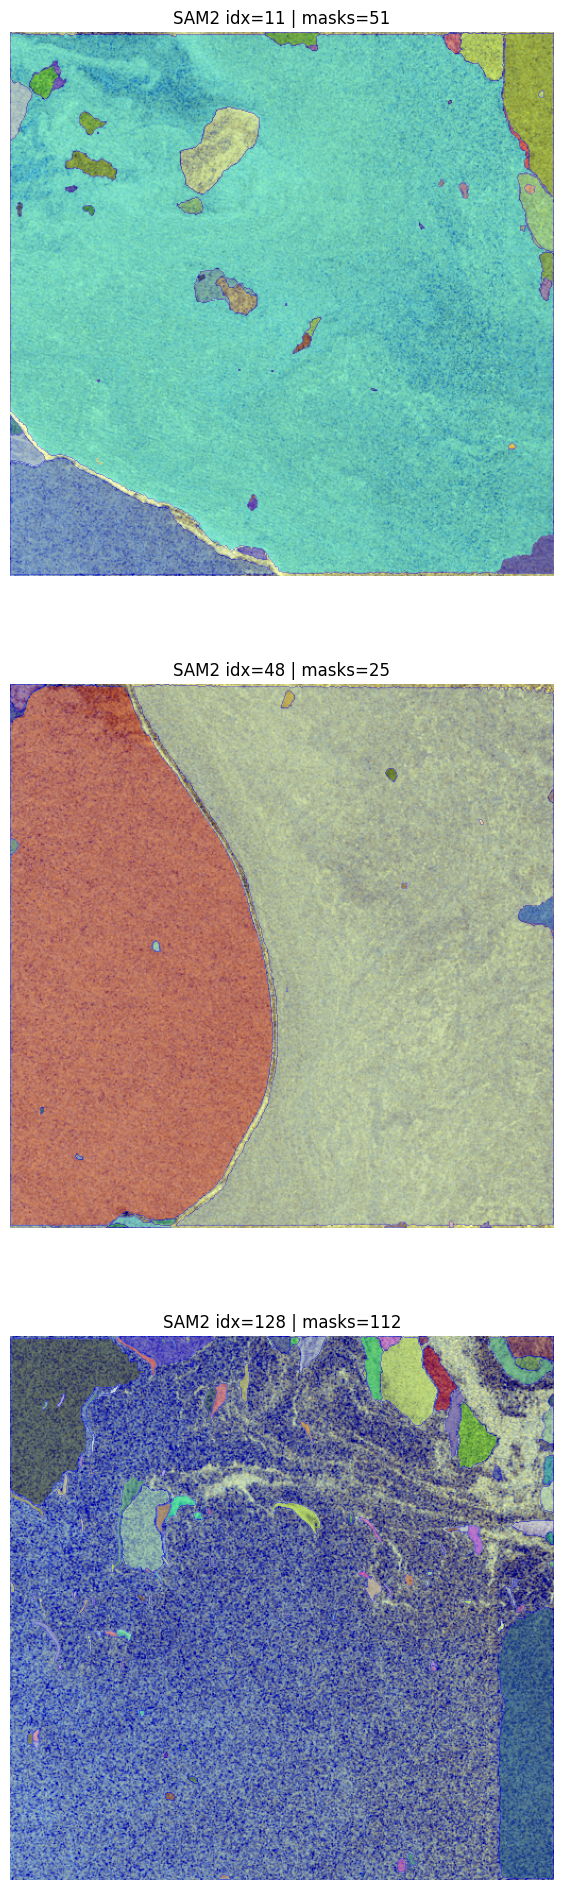

In [13]:
show_sam_result(raw_results)

In [14]:
analyzed_results = [analyze_sample(item) for item in raw_results]
len(analyzed_results)

3

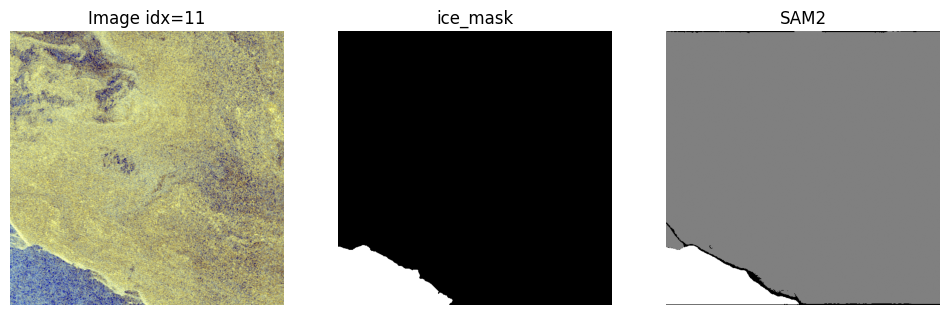

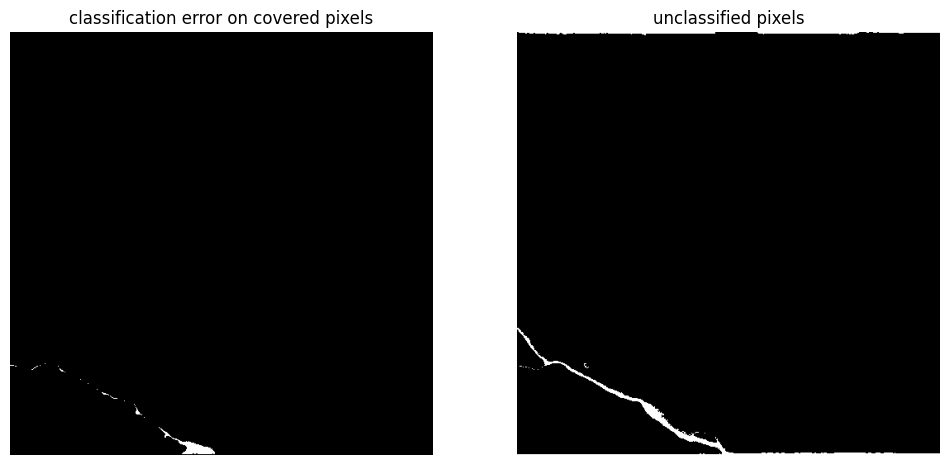

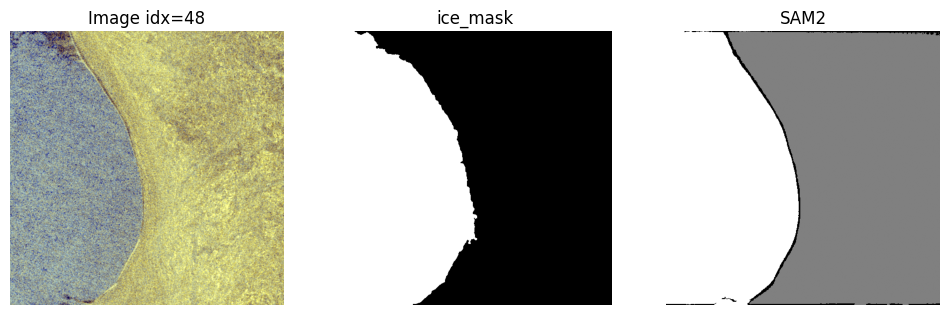

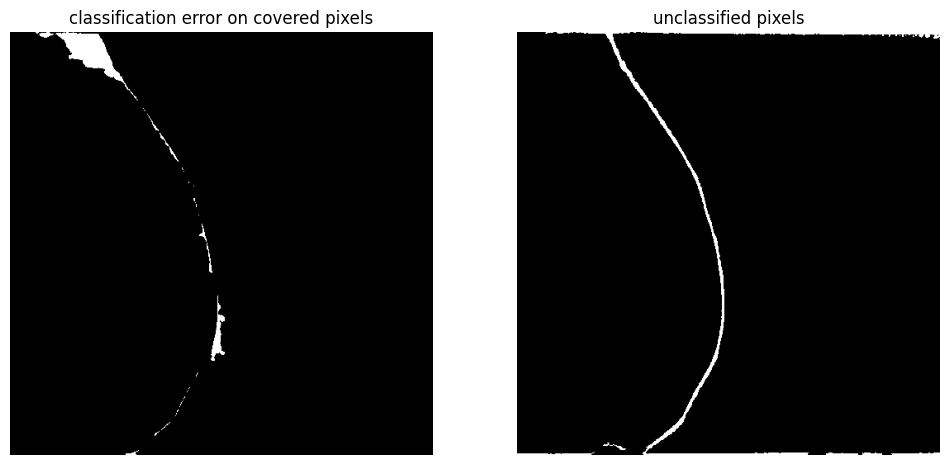

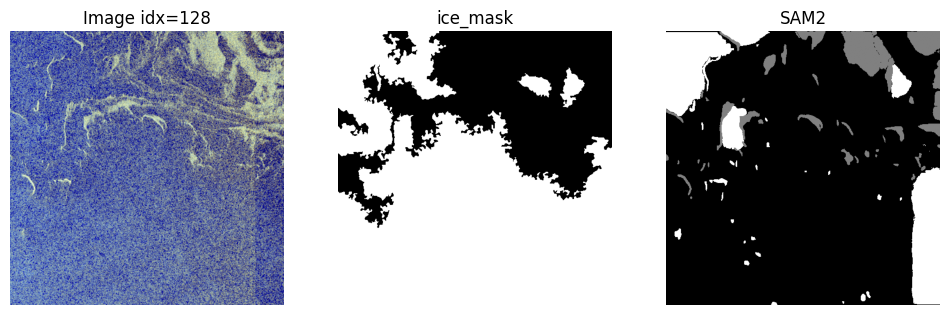

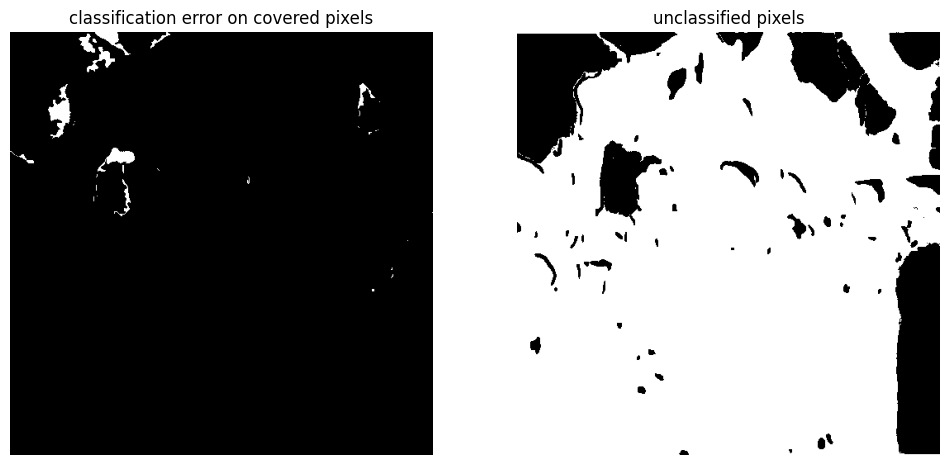

In [15]:
for item in analyzed_results:
    plot_prediction_comparison(item)
    plot_error_maps(item)